In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load your master table
df = pd.read_csv('olist_master_cleaned.csv')

# Quick sanity check
print(df.shape)
print(df.dtypes)
print(df['is_late'].value_counts())
print(df['delivery_delay_days'].describe())

(113425, 39)
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
delivery_delay_days              float64
is_late                            int64
payment_value                    float64
payment_installments             float64
order_item_id                    float64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
pro

In [3]:
#Which sellers are high volume AND high risk?
seller_stats = df.groupby('seller_id').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    total_gmv=('payment_value', 'sum'),
    avg_review=('review_score', 'mean')
).reset_index()

seller_stats['late_rate'] = (seller_stats['late_orders'] / seller_stats['total_orders']) * 100

# Only sellers with enough volume to be meaningful
seller_stats = seller_stats[seller_stats['total_orders'] >= 50]

# Quadrant thresholds — use medians
late_threshold = seller_stats['late_rate'].median()
review_threshold = seller_stats['avg_review'].median()

def assign_quadrant(row):
    if row['late_rate'] >= late_threshold and row['avg_review'] < review_threshold:
        return 'Critical'        # High late rate, low reviews — act immediately
    elif row['late_rate'] >= late_threshold and row['avg_review'] >= review_threshold:
        return 'At Risk'         # High late rate but ratings holding — warning zone
    elif row['late_rate'] < late_threshold and row['avg_review'] < review_threshold:
        return 'Poor Quality'    # On time but bad reviews — product/service issue
    else:
        return 'Star'            # Low late rate, high reviews — benchmark these

seller_stats['quadrant'] = seller_stats.apply(assign_quadrant, axis=1)

print(seller_stats['quadrant'].value_counts())
print(f"\nGMV in Critical quadrant: ${seller_stats[seller_stats['quadrant']=='Critical']['total_gmv'].sum():,.0f}")

quadrant
Critical        155
Star            155
Poor Quality     79
At Risk          79
Name: count, dtype: int64

GMV in Critical quadrant: $5,654,589


In [7]:
fig = px.scatter(
    seller_stats,
    x='late_rate',
    y='avg_review',
    size='total_gmv',
    color='quadrant',
    hover_data=['seller_id', 'total_orders', 'total_gmv'],
    color_discrete_map={
        'Critical': '#d62728',
        'At Risk': '#ff7f0e',
        'Poor Quality': '#9467bd',
        'Star': '#2ca02c'
    },
    title='Seller Performance Quadrant — Late Rate vs Review Score (bubble = GMV)',
    labels={'late_rate': 'Late Delivery Rate (%)', 'avg_review': 'Avg Review Score'}
)

# Add quadrant lines
fig.add_hline(y=review_threshold, line_dash='dash', line_color='grey', opacity=0.5)
fig.add_vline(x=late_threshold, line_dash='dash', line_color='grey', opacity=0.5)

fig.update_layout(height=550)

fig.write_html('outputs/seller_quadrant.html')

In [8]:
#Revenue Impact Calculation

# Assumption (document this clearly)
REORDER_LOSS_RATE = 0.25  # 25% of customers who receive late orders don't reorder
AVG_CUSTOMER_LTV_MULTIPLIER = 3  # avg customer places 3 orders in their lifetime

late_orders = df[df['is_late'] == 1]
ontime_orders = df[df['is_late'] == 0]

total_gmv = df['payment_value'].sum()
late_gmv = late_orders['payment_value'].sum()
late_order_count = len(late_orders)
total_order_count = len(df)

# Direct revenue at risk (current orders)
direct_revenue_at_risk = late_gmv * REORDER_LOSS_RATE

# LTV at risk (future orders lost)
ltv_at_risk = direct_revenue_at_risk * AVG_CUSTOMER_LTV_MULTIPLIER

print("=" * 50)
print("REVENUE IMPACT SUMMARY")
print("=" * 50)
print(f"Total Orders Analyzed:        {total_order_count:,}")
print(f"Late Orders:                  {late_order_count:,} ({late_order_count/total_order_count*100:.1f}%)")
print(f"Total GMV:                    ${total_gmv:,.0f}")
print(f"GMV from Late Orders:         ${late_gmv:,.0f} ({late_gmv/total_gmv*100:.1f}%)")
print(f"Direct Revenue At Risk:       ${direct_revenue_at_risk:,.0f}")
print(f"LTV Revenue At Risk:          ${ltv_at_risk:,.0f}")
print("=" * 50)
print(f"TOTAL ESTIMATED IMPACT:       ${direct_revenue_at_risk + ltv_at_risk:,.0f}")

REVENUE IMPACT SUMMARY
Total Orders Analyzed:        113,425
Late Orders:                  7,265 (6.4%)
Total GMV:                    $20,470,727
GMV from Late Orders:         $1,368,553 (6.7%)
Direct Revenue At Risk:       $342,138
LTV Revenue At Risk:          $1,026,415
TOTAL ESTIMATED IMPACT:       $1,368,553


In [10]:
# Waterfall chart — shows the story visually
categories = ['Total GMV', 'On-Time GMV', 'Late GMV', 'Direct At Risk', 'LTV At Risk']
values = [total_gmv, total_gmv - late_gmv, late_gmv, direct_revenue_at_risk, ltv_at_risk]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

fig = go.Figure(go.Bar(
    x=categories,
    y=values,
    marker_color=colors,
    text=[f'${v:,.0f}' for v in values],
    textposition='outside'
))

fig.update_layout(
    title='Revenue Impact Waterfall — Late Delivery Cost Analysis',
    yaxis_title='USD',
    height=450
)

fig.write_html('outputs/revenue_impact.html')

In [11]:
#Delay Severity vs Review Score
# Create delay buckets
def delay_bucket(days):
    if days <= 0:
        return '0 - On Time / Early'
    elif days <= 3:
        return '1 - Late 1-3 days'
    elif days <= 7:
        return '2 - Late 4-7 days'
    elif days <= 14:
        return '3 - Late 8-14 days'
    else:
        return '4 - Late 14+ days'

df['delay_bucket'] = df['delivery_delay_days'].apply(delay_bucket)

bucket_analysis = df.groupby('delay_bucket').agg(
    order_count=('order_id', 'count'),
    avg_review=('review_score', 'mean'),
    total_gmv=('payment_value', 'sum')
).reset_index().sort_values('delay_bucket')

print(bucket_analysis)

          delay_bucket  order_count  avg_review    total_gmv
0  0 - On Time / Early       102931    4.208268  18407117.52
1    1 - Late 1-3 days         2110    3.230843    363056.46
2    2 - Late 4-7 days         2007    2.089810    392339.34
3   3 - Late 8-14 days         1618    1.685841    308985.89
4    4 - Late 14+ days         4759    1.734122    999227.45


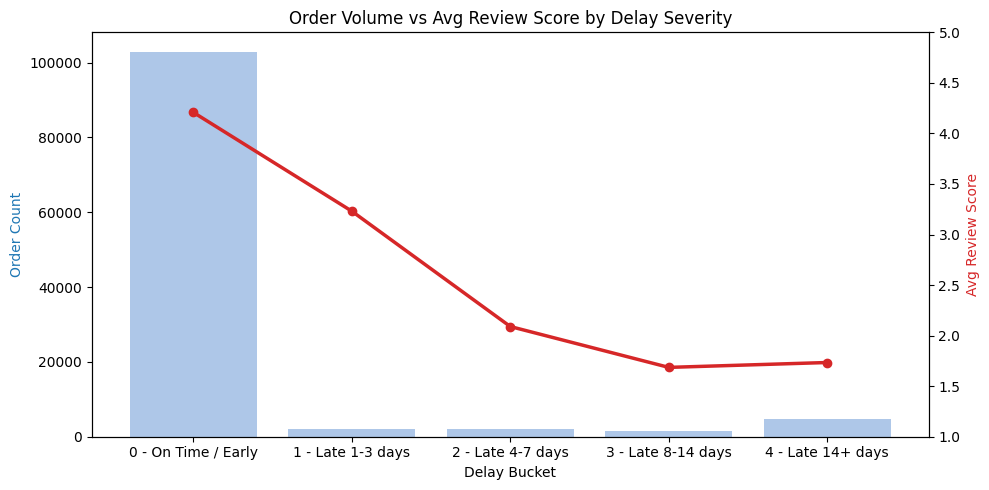

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(bucket_analysis['delay_bucket'], bucket_analysis['order_count'],
               color='#aec7e8', label='Order Count')
ax1.set_ylabel('Order Count', color='#1f77b4')
ax1.set_xlabel('Delay Bucket')

ax2 = ax1.twinx()
ax2.plot(bucket_analysis['delay_bucket'], bucket_analysis['avg_review'],
         color='#d62728', marker='o', linewidth=2.5, label='Avg Review Score')
ax2.set_ylabel('Avg Review Score', color='#d62728')
ax2.set_ylim(1, 5)

plt.title('Order Volume vs Avg Review Score by Delay Severity')
fig.tight_layout()
plt.savefig('outputs/delay_severity.png', dpi=150)
plt.show()

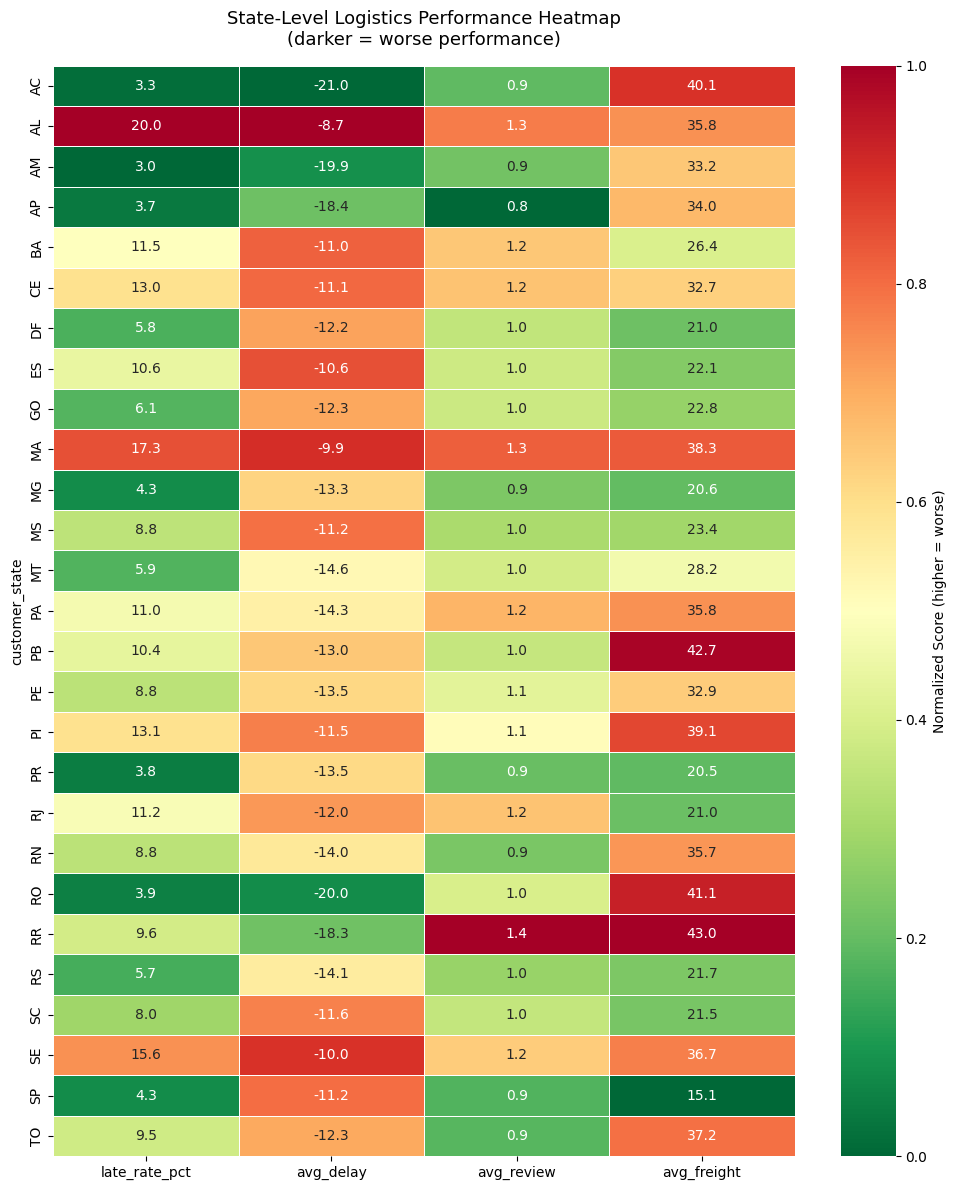

In [15]:
# Is this a regional infrastructure problem or spread evenly?
state_stats = df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    avg_review=('review_score', 'mean'),
    avg_freight=('freight_value', 'mean'),
    total_gmv=('payment_value', 'sum')
).reset_index()

state_stats['late_rate_pct'] = state_stats['late_rate'] * 100
state_stats = state_stats[state_stats['total_orders'] >= 50]

# Heatmap of key metrics by state
heatmap_data = state_stats[['customer_state', 'late_rate_pct', 'avg_delay', 
                              'avg_review', 'avg_freight']].set_index('customer_state')

# Run this BEFORE normalization
heatmap_data['avg_review'] = 5 - heatmap_data['avg_review'] 
# Now a 1-star review becomes '4' (High/Red) and a 5-star becomes '0' (Low/Green)

# Normalize for heatmap
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=heatmap_data.columns,
    index=heatmap_data.index
)

plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_normalized,
    annot=heatmap_data.round(1),  # show actual values
    fmt='',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Score (higher = worse)'}
)
plt.title('State-Level Logistics Performance Heatmap\n(darker = worse performance)', 
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('outputs/state_heatmap.png', dpi=150)
plt.show()

In [17]:
#Are we paying more in freight for states that still deliver late?

fig = px.scatter(
    state_stats,
    x='avg_freight',
    y='late_rate_pct',
    size='total_orders',
    color='avg_review',
    text='customer_state',
    color_continuous_scale='RdYlGn',
    title='Freight Cost vs Late Delivery Rate by State\n(bubble = order volume, color = avg review)',
    labels={
        'avg_freight': 'Avg Freight Cost (R$)',
        'late_rate_pct': 'Late Delivery Rate (%)',
        'avg_review': 'Avg Review'
    }
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=550)

fig.write_html('outputs/freight_vs_delay.html')

In [20]:
# Is it a product handling problem or a seller process problem?

category_stats = df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean'),
    avg_review=('review_score', 'mean'),
    avg_delay=('delivery_delay_days', 'mean')
).reset_index()

category_stats = category_stats[category_stats['total_orders'] >= 100]
category_stats['late_rate_pct'] = category_stats['late_rate'] * 100
top_categories = category_stats.nlargest(15, 'late_rate_pct')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_categories['product_category_name_english'],
               top_categories['late_rate_pct'],
               color=plt.cm.RdYlGn_r(top_categories['late_rate_pct'] / 100))

ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Top 15 Product Categories by Late Delivery Rate\n(min 100 orders)', fontsize=12)
ax.axvline(x=df['is_late'].mean() * 100, color='navy', 
           linestyle='--', label=f'Overall Avg: {df["is_late"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/category_late_rate.png', dpi=150)
plt.show()

KeyError: 'product_category_name_english'